# Inasistencias por seguimiento, grupo, programa y sede

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)

In [2]:
# Programas excluidos de la analítica
EXCLUIR_PROGRAMAS = [
    "TecLab-AuxAdmin",
    "TecLab-MarkDig",
    "CIES-Univ",
    "CIES-RAF-FICAT",
    "DiploHASPS-1",
    "DiploHCNSPS-1",
]

In [3]:
detalle = pd.read_csv("../data/raw/inasistencias_detalle.csv")
est = pd.read_csv("../data/raw/estudiantes.csv")

print(f"Inasistencias detalle: {len(detalle):,}")
print(f"Estudiantes: {len(est):,}")
detalle.head(2)

Inasistencias detalle: 23,178
Estudiantes: 882


,Numero_identificacion_estudiante,Nombre_completo_estudiante,Sexo,Correo_electronico,Celular,Codigo_curso,Nombre_curso,Codigo_modulo,Nombre_modulo,Horario_curso,Periodo_curso,Numero_identificacion_docente,Nombre_docente,Cantidad_inasistencia,Dia,Fecha_inasistencia,Hora,Justificacion,Detalle_justificacion
0,1082875010,ADALBERTO ADARRAGA CONTRERAS,M,beto10162014@gmail.com,3233892635,261-BAS,261-BAS-42040101-COMUNICACIÓN ESCRITA,42040101,COMUNICACIÓN ESCRITA,NaN,2026-1,79594845,Cortés Núñez José Antonio,11,martes,2026-03-10,06:00 p. m. - 08:00 p. m.,False,NaN
1,1082875010,ADALBERTO ADARRAGA CONTRERAS,M,beto10162014@gmail.com,3233892635,261-BAS,261-BAS-42040101-COMUNICACIÓN ESCRITA,42040101,COMUNICACIÓN ESCRITA,NaN,2026-1,79594845,Cortés Núñez José Antonio,11,martes,2026-04-21,06:00 p. m. - 08:00 p. m.,False,NaN


In [4]:
# Merge con datos de estudiantes (programa, sede)
info_est = est[["Numero_identificacion", "Codigo_programa", "Nombre_programa_limpio", "Sede"]].drop_duplicates(
    subset="Numero_identificacion"
)

df = detalle.merge(
    info_est,
    left_on="Numero_identificacion_estudiante",
    right_on="Numero_identificacion",
    how="left",
)

df["Fecha_inasistencia"] = pd.to_datetime(df["Fecha_inasistencia"], errors="coerce")
print(f"Sin datos de programa/sede: {df['Nombre_programa_limpio'].isna().sum():,}")
df.head(2)

Sin datos de programa/sede: 5,461


,Numero_identificacion_estudiante,Nombre_completo_estudiante,Sexo,Correo_electronico,Celular,Codigo_curso,Nombre_curso,Codigo_modulo,Nombre_modulo,Horario_curso,...,Cantidad_inasistencia,Dia,Fecha_inasistencia,Hora,Justificacion,Detalle_justificacion,Numero_identificacion,Codigo_programa,Nombre_programa_limpio,Sede
0,1082875010,ADALBERTO ADARRAGA CONTRERAS,M,beto10162014@gmail.com,3233892635,261-BAS,261-BAS-42040101-COMUNICACIÓN ESCRITA,42040101,COMUNICACIÓN ESCRITA,NaN,...,11,martes,2026-03-10,06:00 p. m. - 08:00 p. m.,False,NaN,1.082875e+09,Tecnolog-Logis-Bas,TECNOLOGÍA EN GESTIÓN DE OPERACIONES LOGÍSTICAS,BASTIDAS
1,1082875010,ADALBERTO ADARRAGA CONTRERAS,M,beto10162014@gmail.com,3233892635,261-BAS,261-BAS-42040101-COMUNICACIÓN ESCRITA,42040101,COMUNICACIÓN ESCRITA,NaN,...,11,martes,2026-04-21,06:00 p. m. - 08:00 p. m.,False,NaN,1.082875e+09,Tecnolog-Logis-Bas,TECNOLOGÍA EN GESTIÓN DE OPERACIONES LOGÍSTICAS,BASTIDAS


In [5]:
# Filtrar programas excluidos
antes = len(df)
df = df[~df["Codigo_programa"].isin(EXCLUIR_PROGRAMAS)].copy()
print(f"Registros eliminados: {antes - len(df):,}")
print(f"Registros después del filtro: {len(df):,}")

Registros eliminados: 0
Registros después del filtro: 23,178


In [ ]:
# Configuración de grupos y fechas
PROGRAMAS_GRUPO_B = ["TECNOLOGÍA EN GESTIÓN DE PRODUCCIÓN DE MODAS"]
SEDES_GRUPO_B = ["MINCA", "BURITACA"]

CORTES_A = pd.to_datetime(["2026-02-01", "2026-03-15", "2026-04-19", "2026-05-30"])
ETIQUETAS_A = [
    "Seguimiento 1",
    "Seguimiento 2",
    "Seguimiento 3",
]

CORTES_B = pd.to_datetime(["2026-04-06", "2026-05-10", "2026-06-14", "2026-07-26"])
ETIQUETAS_B = [
    "Seguimiento 1",
    "Seguimiento 2",
    "Seguimiento 3",
]

In [7]:
# Asignar grupo (A o B) según programa o sede
def asignar_grupo(row):
    prog = str(row.get("Nombre_programa_limpio", "") or "").strip().upper()
    sede = str(row.get("Sede", "") or "").strip().upper()
    if prog in [p.upper() for p in PROGRAMAS_GRUPO_B] or sede in [s.upper() for s in SEDES_GRUPO_B]:
        return "B"
    return "A"

df["Grupo"] = df.apply(asignar_grupo, axis=1)

In [8]:
# Clasificar cada falta en un seguimiento según su fecha y grupo
def clasificar_seguimiento(fecha, grupo):
    cortes = CORTES_B if grupo == "B" else CORTES_A
    etiquetas = ETIQUETAS_B if grupo == "B" else ETIQUETAS_A
    for i in range(len(etiquetas)):
        if cortes[i] <= fecha < cortes[i + 1]:
            return etiquetas[i]
    return None

df["Seguimiento"] = df.apply(
    lambda r: clasificar_seguimiento(r["Fecha_inasistencia"], r["Grupo"])
    if pd.notna(r["Fecha_inasistencia"])
    else None,
    axis=1,
)

print(f"Registros totales: {len(df):,}")
print(f"Sin seguimiento (fuera de rango): {df['Seguimiento'].isna().sum():,}")
df.head(2)

Registros totales: 23,178
Sin seguimiento (fuera de rango): 1,205


,Numero_identificacion_estudiante,Nombre_completo_estudiante,Sexo,Correo_electronico,Celular,Codigo_curso,Nombre_curso,Codigo_modulo,Nombre_modulo,Horario_curso,...,Fecha_inasistencia,Hora,Justificacion,Detalle_justificacion,Numero_identificacion,Codigo_programa,Nombre_programa_limpio,Sede,Grupo,Seguimiento
0,1082875010,ADALBERTO ADARRAGA CONTRERAS,M,beto10162014@gmail.com,3233892635,261-BAS,261-BAS-42040101-COMUNICACIÓN ESCRITA,42040101,COMUNICACIÓN ESCRITA,NaN,...,2026-03-10,06:00 p. m. - 08:00 p. m.,False,NaN,1.082875e+09,Tecnolog-Logis-Bas,TECNOLOGÍA EN GESTIÓN DE OPERACIONES LOGÍSTICAS,BASTIDAS,A,Seguimiento 1 (01 Feb – 01 Abr)
1,1082875010,ADALBERTO ADARRAGA CONTRERAS,M,beto10162014@gmail.com,3233892635,261-BAS,261-BAS-42040101-COMUNICACIÓN ESCRITA,42040101,COMUNICACIÓN ESCRITA,NaN,...,2026-04-21,06:00 p. m. - 08:00 p. m.,False,NaN,1.082875e+09,Tecnolog-Logis-Bas,TECNOLOGÍA EN GESTIÓN DE OPERACIONES LOGÍSTICAS,BASTIDAS,A,Seguimiento 2 (02 Abr – 13 May)


## 1. Inasistencias por grupo (A / B)

,Grupo,Inasistencias
0,A,20113
1,B,3065


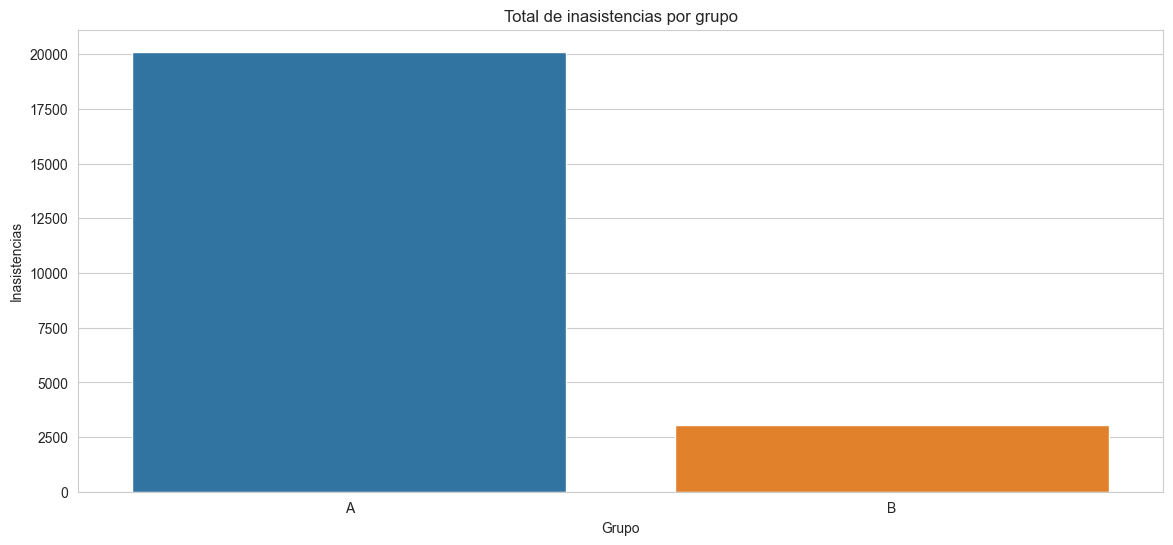

In [9]:
por_grupo = df.groupby("Grupo").size().reset_index(name="Inasistencias")
display(por_grupo)

sns.barplot(data=por_grupo, x="Grupo", y="Inasistencias", hue="Grupo", legend=False)
plt.title("Total de inasistencias por grupo")
plt.show()

## 2. Inasistencias por seguimiento

,Seguimiento,Inasistencias
0,Seguimiento 1 (01 Feb – 01 Abr),8958
1,Seguimiento 1 (06 Abr – 09 May),862
2,Seguimiento 2 (02 Abr – 13 May),7870
3,Seguimiento 2 (10 May – 13 Jun),998
4,Seguimiento 3 (14 May – 25 Jun),3285


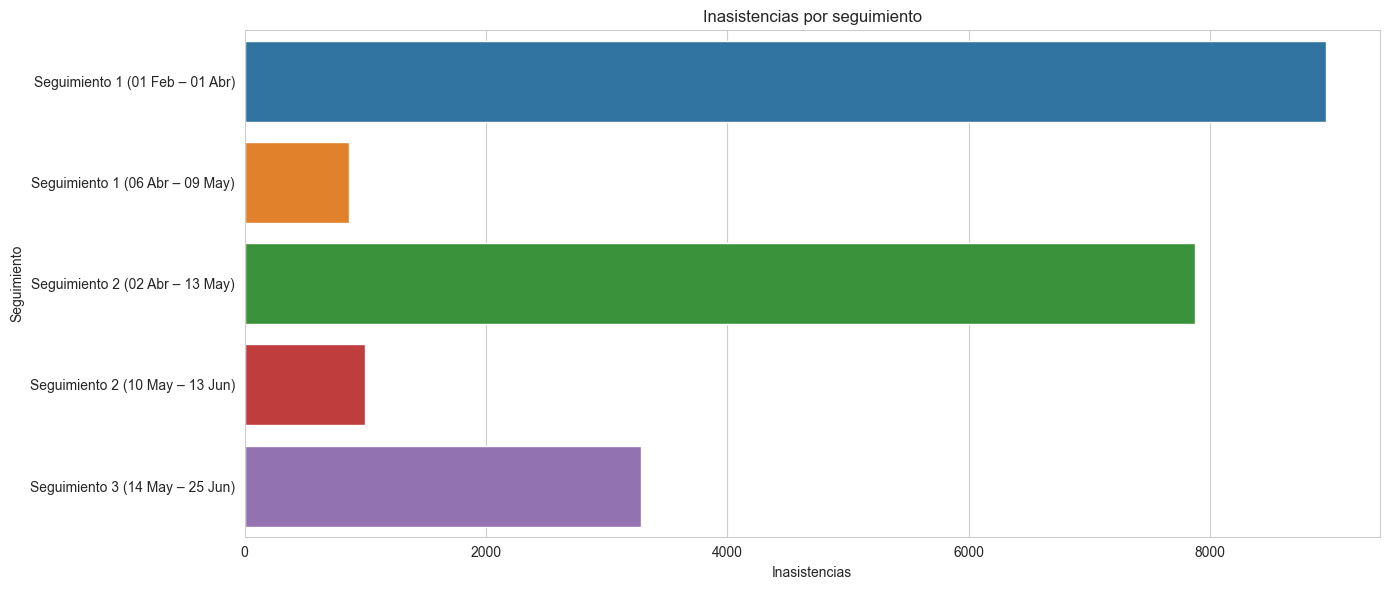

In [10]:
por_seg = df.groupby("Seguimiento").size().reset_index(name="Inasistencias")
display(por_seg)

sns.barplot(data=por_seg, y="Seguimiento", x="Inasistencias", hue="Seguimiento", legend=False)
plt.title("Inasistencias por seguimiento")
plt.tight_layout()
plt.show()

## 3. Inasistencias por grupo + seguimiento

,Grupo,Seguimiento,Inasistencias
0,A,Seguimiento 1 (01 Feb – 01 Abr),8958
1,A,Seguimiento 2 (02 Abr – 13 May),7870
2,A,Seguimiento 3 (14 May – 25 Jun),3285
3,B,Seguimiento 1 (06 Abr – 09 May),862
4,B,Seguimiento 2 (10 May – 13 Jun),998


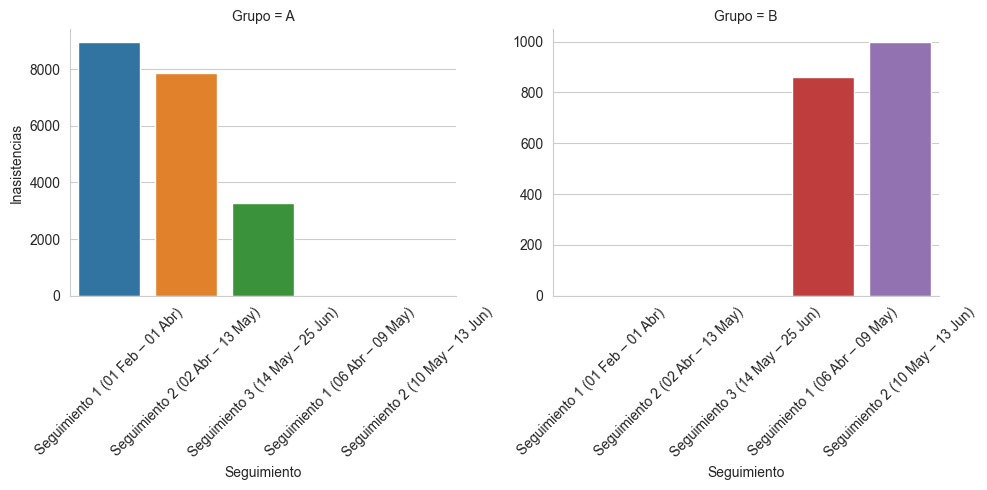

In [11]:
por_grupo_seg = df.groupby(["Grupo", "Seguimiento"]).size().reset_index(name="Inasistencias")
display(por_grupo_seg)

g = sns.catplot(data=por_grupo_seg, x="Seguimiento", y="Inasistencias",
                col="Grupo", kind="bar", hue="Seguimiento", legend=False, sharey=False)
g.set_xticklabels(rotation=45)
plt.tight_layout()
plt.show()

## 4. Inasistencias por programa

,Nombre_programa_limpio,Inasistencias
4,TECNOLOGÍA EN MARKETING DIGITAL,5320
0,TECNOLOGÍA EN GESTIÓN DE OPERACIONES LOGÍSTICAS,5239
2,TECNOLOGÍA EN GESTIÓN DE SERVICIOS GASTRONÓMICOS,3628
3,TECNOLOGÍA EN GESTIÓN DEL TURISMO CULTURAL Y D...,2972
1,TECNOLOGÍA EN GESTIÓN DE PRODUCCIÓN DE MODAS,558


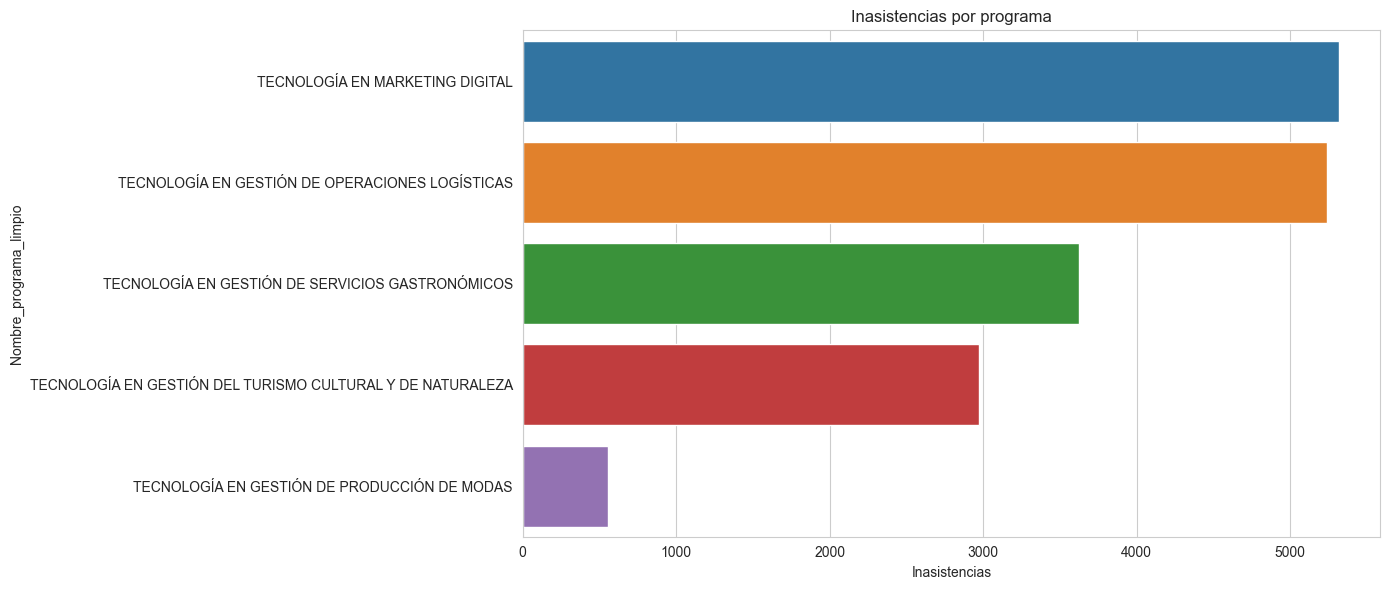

In [12]:
por_programa = df.groupby("Nombre_programa_limpio").size().reset_index(name="Inasistencias").sort_values("Inasistencias", ascending=False)
display(por_programa)

sns.barplot(data=por_programa, y="Nombre_programa_limpio", x="Inasistencias", hue="Nombre_programa_limpio", legend=False)
plt.title("Inasistencias por programa")
plt.tight_layout()
plt.show()

## 5. Inasistencias por sede

,Sede,Inasistencias
2,INEM,9854
0,BASTIDAS,3057
4,PESCAITO,2299
3,MINCA,1262
1,BURITACA,1245


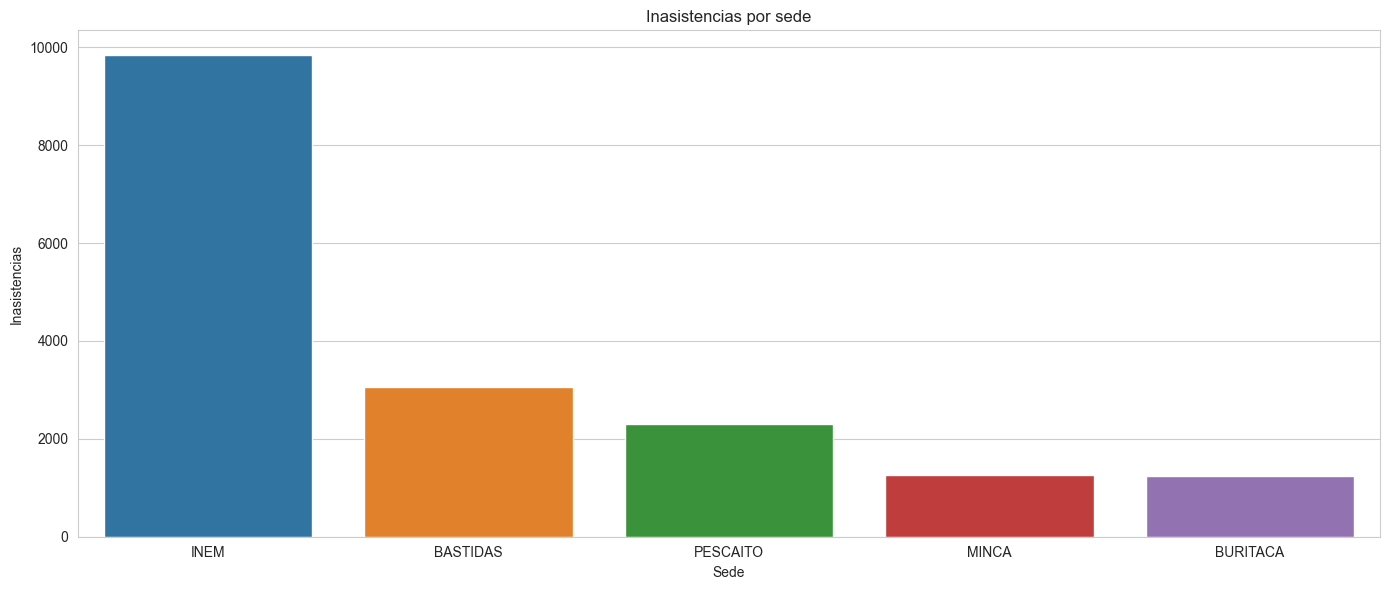

In [13]:
por_sede = df.groupby("Sede").size().reset_index(name="Inasistencias").sort_values("Inasistencias", ascending=False)
display(por_sede)

sns.barplot(data=por_sede, x="Sede", y="Inasistencias", hue="Sede", legend=False)
plt.title("Inasistencias por sede")
plt.tight_layout()
plt.show()

## 6. Tabla cruzada: Programa × Seguimiento

Seguimiento,Seguimiento 1 (01 Feb – 01 Abr),Seguimiento 1 (06 Abr – 09 May),Seguimiento 2 (02 Abr – 13 May),Seguimiento 2 (10 May – 13 Jun),Seguimiento 3 (14 May – 25 Jun)
Nombre_programa_limpio,,,,,
TECNOLOGÍA EN GESTIÓN DE OPERACIONES LOGÍSTICAS,2128,0,2114,0,997
TECNOLOGÍA EN GESTIÓN DE PRODUCCIÓN DE MODAS,0,144,0,414,0
TECNOLOGÍA EN GESTIÓN DE SERVICIOS GASTRONÓMICOS,1832,0,1253,0,543
TECNOLOGÍA EN GESTIÓN DEL TURISMO CULTURAL Y DE NATURALEZA,815,294,714,224,275
TECNOLOGÍA EN MARKETING DIGITAL,1762,424,1489,360,730


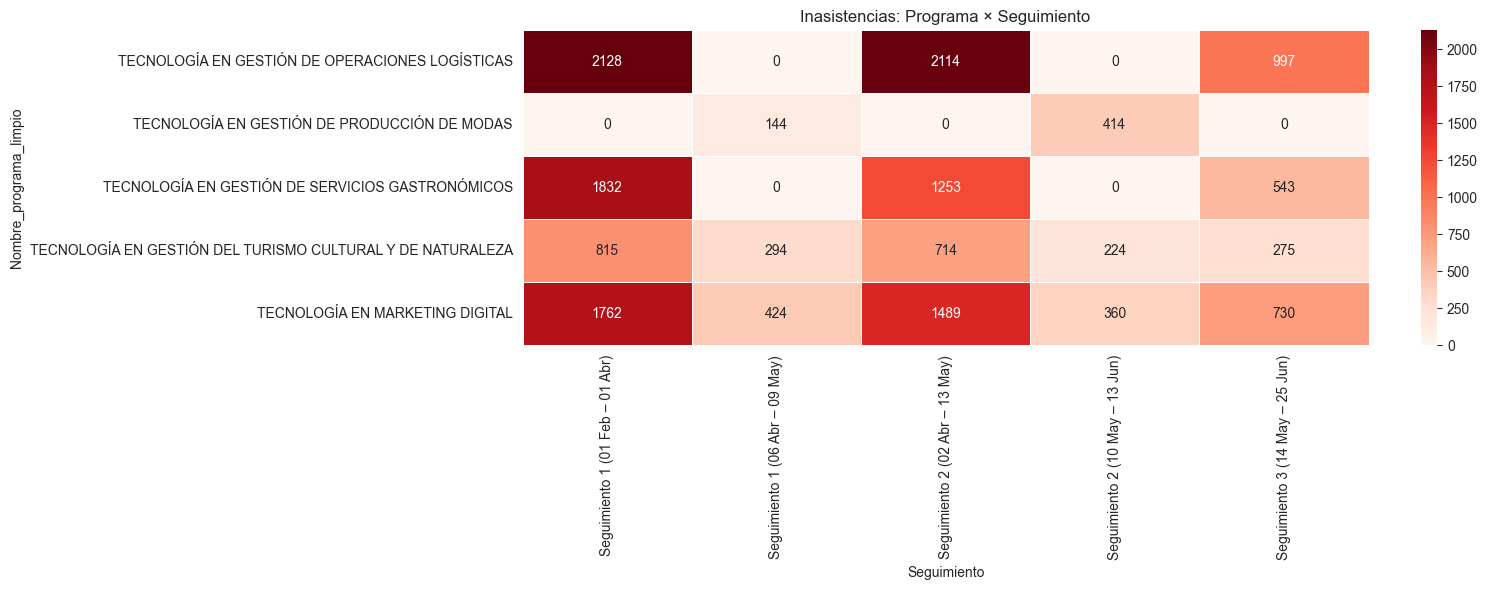

In [14]:
cruzada = df.pivot_table(index="Nombre_programa_limpio", columns="Seguimiento", aggfunc="size", fill_value=0)
display(cruzada)

plt.figure(figsize=(16, max(6, len(cruzada) * 0.4)))
sns.heatmap(cruzada, annot=True, fmt="d", cmap="Reds", linewidths=0.5)
plt.title("Inasistencias: Programa × Seguimiento")
plt.tight_layout()
plt.show()

## 7. Tabla cruzada: Sede × Seguimiento

Seguimiento,Seguimiento 1 (01 Feb – 01 Abr),Seguimiento 1 (06 Abr – 09 May),Seguimiento 2 (02 Abr – 13 May),Seguimiento 2 (10 May – 13 Jun),Seguimiento 3 (14 May – 25 Jun)
Sede,,,,,
BASTIDAS,1325,0,1196,0,536
BURITACA,0,383,0,303,0
INEM,4114,144,3575,414,1607
MINCA,0,335,0,281,0
PESCAITO,1098,0,799,0,402


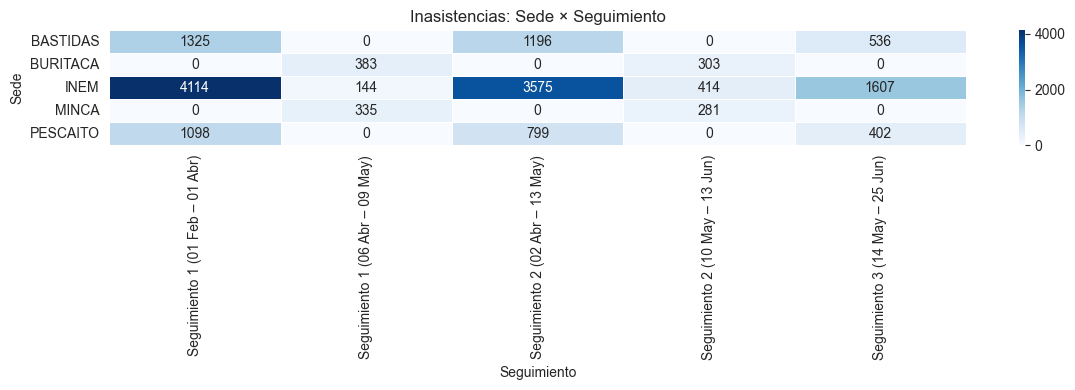

In [15]:
cruzada_sede = df.pivot_table(index="Sede", columns="Seguimiento", aggfunc="size", fill_value=0)
display(cruzada_sede)

plt.figure(figsize=(12, max(4, len(cruzada_sede) * 0.5)))
sns.heatmap(cruzada_sede, annot=True, fmt="d", cmap="Blues", linewidths=0.5)
plt.title("Inasistencias: Sede × Seguimiento")
plt.tight_layout()
plt.show()

## 8. Inasistencias por curso

,Nombre_curso,Grupo,Inasistencias
8,261-BAS-42040102-HERRAMIENTAS TICS,A,557
3,261-BAS-42010104-INGLÉS I,A,435
51,261-INE-13070212-INGLÉS TÉCNICO II (2),A,407
10,261-BAS-42040104-INGLÉS I,A,310
216,261-PES-42040102-HERRAMIENTAS TICS,A,297
211,261-PES-42010104-INGLÉS I,A,295
218,261-PES-42040104-INGLÉS I,A,294
9,261-BAS-42040103-RAZONAMIENTO CUANTITATIVO,A,285
45,261-INE-13070210-PREPARACIÓN DE INFORMES (2),A,260
13,261-BAS-42040107-GESTIÓN NAVIERA Y PORTUARIA,A,247


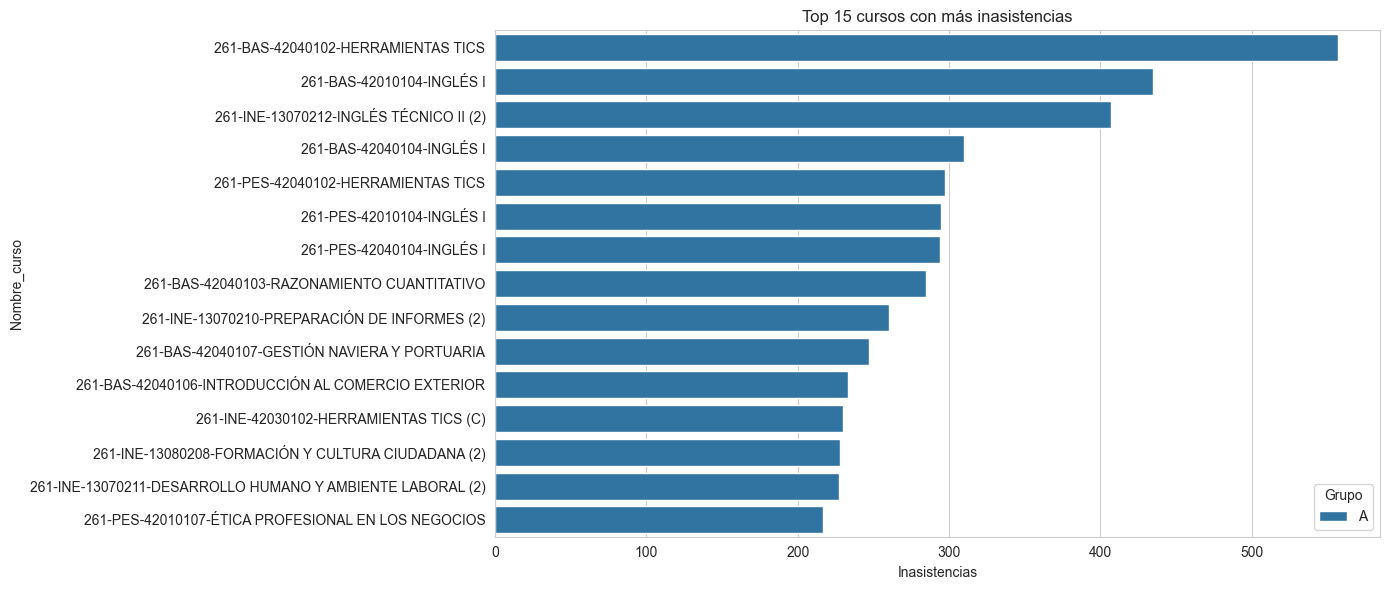

In [16]:
por_curso = df.groupby(["Nombre_curso", "Grupo"]).size().reset_index(name="Inasistencias").sort_values("Inasistencias", ascending=False)
display(por_curso.head(20))

top_cursos = por_curso.head(15)
sns.barplot(data=top_cursos, y="Nombre_curso", x="Inasistencias", hue="Grupo", dodge=False)
plt.title("Top 15 cursos con más inasistencias")
plt.tight_layout()
plt.show()

## 9. Resumen

In [17]:
print("=== RESUMEN ===")
print(f"Total inasistencias: {len(df):,}")
print(f"Estudiantes: {df['Numero_identificacion_estudiante'].nunique():,}")
print(f"Justificadas: {df['Justificacion'].sum():,} ({df['Justificacion'].mean()*100:.1f}%)")
print(f"Cursos: {df['Nombre_curso'].nunique()}")
print(f"Programas: {df['Nombre_programa_limpio'].nunique()}")
print(f"Sedes: {df['Sede'].nunique()}")

=== RESUMEN ===
Total inasistencias: 23,178
Estudiantes: 1,023
Justificadas: 7,282 (31.4%)
Cursos: 220
Programas: 5
Sedes: 5


In [18]:
# Programas que quedaron después del filtro
print("Programas incluidos en el análisis:")
for p in sorted(df['Codigo_programa'].unique()):
    print(f"  - {p}")

Programas incluidos en el análisis:


TypeError: '<' not supported between instances of 'float' and 'str'